In [10]:

# You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
# Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. 
# After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
# Your goal is to minimise side effects; in this competition, 
# it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 
# 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

# week1_X = [0.886456, 0.404712, 0.000098]
# week1_y = -0.132677666460545

# # 0.886456-0.404712-0.000098

# X = np.vstack([X, week1_X])
# y = np.append(y, week1_y)

# X_initial and y_initial should already exist from baseline points
X_initial = X.copy()
y_initial = y.copy()

X_weekly_list = []
y_weekly_list = []

# --- WEEKLY UPDATE SECTION ---
new_queries = [
    [0.886456, 0.404712, 0.000098], # Week 1
    [0.896256, 0.685712, 0.858980]  # Week 2
]
new_results = [
    -0.132677666460545, # Week 1
    -0.04049552184408659 # Week 2
]

# Create the "Weekly Only" arrays for your Distance and Sensitivity plots
X_weekly = np.array(new_queries)
y_weekly = np.array(new_results)

# Reference for convenience
X_lastweek = X_weekly[-1]
y_lastweek = y_weekly[-1]

# Automatically update your main dataset
X = np.vstack([X_initial, new_queries])
y = np.append(y_initial, new_results)


print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

-- inputs X ---
[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [8.86456000e-01 4.04712000e-01 9.80000000e-05]
 [8.96256000e-01 6.85712000e-01 8.58980000e-01]]
X shape= (17, 3)
-- outputs y ---
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741

In [11]:
df = pd.DataFrame(X, columns=["x1","x2","X3"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

# week 1 result is in 15th Id last but one 
# 15	0.886456	0.404712	0.000098	-0.132678
# 16	0.896256	0.685712	0.858980	-0.040496 (3rd place)

,x1,x2,X3,y
3,0.492581,0.611593,0.340176,-0.034835
13,0.600097,0.725136,0.066089,-0.036378
16,0.896256,0.685712,0.858980,-0.040496
10,0.220549,0.297825,0.343555,-0.046947
4,0.134622,0.219917,0.458206,-0.048008
14,0.965995,0.861120,0.566829,-0.056758
1,0.242114,0.644074,0.272433,-0.087963
9,0.170477,0.697032,0.149169,-0.094190
11,0.666014,0.671985,0.246295,-0.105965
5,0.345523,0.941360,0.269363,-0.110621


In [12]:
sorted_idx = np.argsort(y)[::-1]
best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

print(sorted_idx)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y_best}")

print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best}, y:{y_third_best}")

[ 3 13 16 10  4 14  1  9 11  5  2  0  7 12  8 15  6]
Current Best x_idx: 3
Current Best x: [0.49258141 0.61159319 0.34017639]
Current Best y: -0.034835313350078584
Current 2nd Best x: [0.60009728 0.72513573 0.06608864], y:-0.036377828071632486
Current 3nd Best x: [0.896256 0.685712 0.85898 ], y:-0.04049552184408659


In [13]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# week 1
# kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5]*3, 
#                                       length_scale_bounds=(1e-2, 1e5), 
#                                       nu=2.5)
# gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=10)
# gp.fit(X, y)

# week 2
kernel = C(1.0) * Matern(length_scale=[0.2, 0.2, 0.2],
                         length_scale_bounds=(1e-2, 1e2), 
                         nu=2.5
                        ) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e0))

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)
gp.fit(X, y)

# Rule of thumb
# small noise: 1e-6 – 1e-3
# noisy (typical in wet-lab), use 1e-2 – 1e-1

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")
# print(f"Final length scale: {gp.kernel_.length_scale}")

# week 1
# Optimized Kernel: 1.25**2 * Matern(length_scale=[9.29e+03, 1e+05, 0.0737], nu=2.5)
# Training R^2 Score: 0.9891343923506392
# Total variance accounted for as noise: 0.1

# week 2
# Optimized Kernel: 1.36**2 * Matern(length_scale=[100, 100, 0.0801], nu=2.5) + WhiteKernel(noise_level=0.0153)
# Training R^2 Score: 0.996392342487966
# Total variance accounted for as noise: 1e-10

# [100, 100, 0.0801]
# x1 and x2 is smooth out and does not contribute to bo, use only x3

Optimized Kernel: 1.48**2 * Matern(length_scale=[100, 100, 0.0957], nu=2.5) + WhiteKernel(noise_level=0.0155)
Training R^2 Score: 0.9962365518076933
Total variance accounted for as noise: 1e-10


In [15]:
# Predict
X_grid = np.random.uniform(0, 1, size=(10000, 3))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()


In [16]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"--- Optimization Results ---")
print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")


--- Optimization Results ---
UCB Score with kappa: 2.0
Current Best y: -0.034835313350078584
Suggested next: [0.06302607 0.52221368 0.65313577]


In [17]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"--- Optimization Results ---")
print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ei_next_query}")



--- Optimization Results ---
expected_improvement with xi: 0.01
Current Best y: -0.034835313350078584
Suggested next: [0.90514215 0.63157811 0.39814928]


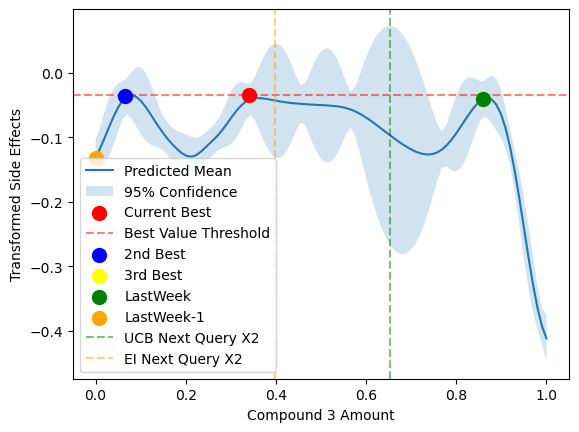

array([0.06302607, 0.52221368, 0.65313577])

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a grid of points for Compound 3 (your most sensitive variable)
# Keep Compound 1 and 2 fixed at your current best levels
x_grid = np.linspace(0, 1, 100)

X_test = np.zeros((len(x_grid), 3))
# Current Best x: [0.49258141 0.61159319 0.34017639]
X_test[:, 0] = x_best[0]  # Fixed C1
X_test[:, 1] = x_best[1] # Fixed C2
X_test[:, 2] = x_grid # Varying C3


# 2. Get predictions from your Gaussian Process
# return_std=True is the key to visualizing uncertainty
mu, sigma = gp.predict(X_test, return_std=True)


lastweek_idx = len(y) - 1
before_1_lastweek_idx = len(y) - 2
this_week_query = ucb_next_query

# 3. Plot
plt.plot(x_grid, mu, label='Predicted Mean')
plt.fill_between(x_grid, mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2, label='95% Confidence')

plt.scatter(X[best_idx, 2], y[best_idx], color='red', s=100, zorder=5, label='Current Best')
plt.axhline(y[best_idx], color='red', linestyle='--', alpha=0.5, label='Best Value Threshold')

plt.scatter(X[second_idx, 2], y[second_idx], color='blue', s=100, zorder=5, label='2nd Best')
plt.scatter(X[third_idx, 2], y[third_idx], color='yellow', s=100, zorder=5, label='3rd Best')
plt.scatter(X[lastweek_idx, 2], y[lastweek_idx], color='green', s=100, zorder=5, label='LastWeek')
plt.scatter(X[before_1_lastweek_idx, 2], y[before_1_lastweek_idx], color='orange', s=100, zorder=5, label='LastWeek-1')

plt.axvline(ucb_next_query[2], color='green', linestyle='--', alpha=0.5, label='UCB Next Query X2')
plt.axvline(ei_next_query[2], color='orange', linestyle='--', alpha=0.5, label='EI Next Query X2')

plt.xlabel('Compound 3 Amount')
plt.ylabel('Transformed Side Effects')
plt.legend()
plt.show()
ucb_next_query

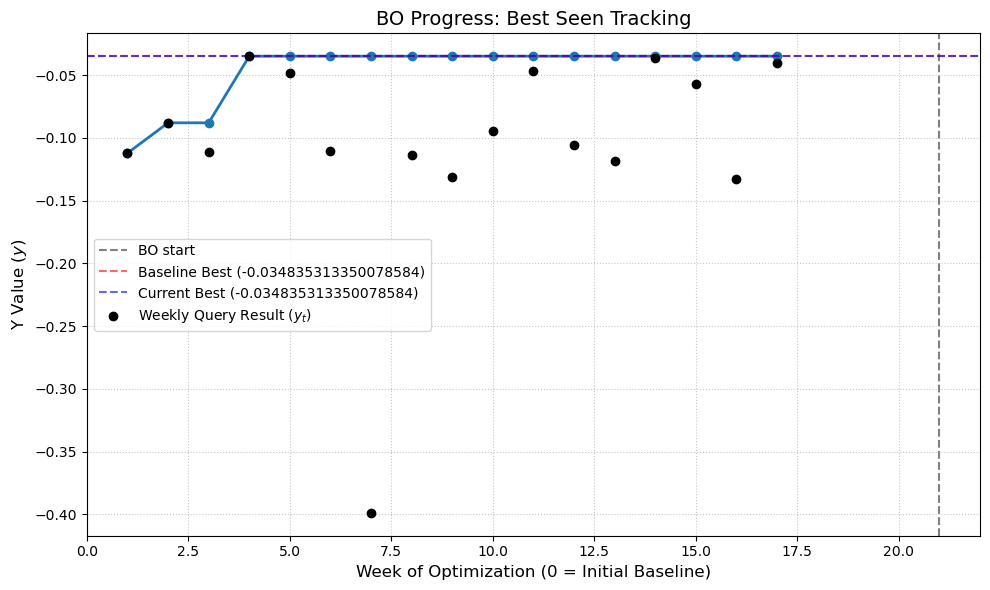

In [20]:
# Convergence Report
y_observed = y
baseline_best = np.max(y_initial)

weekly = np.arange(1, len(y_observed) + 1)
best_seen_trace = np.maximum.accumulate(y_observed)

bo_start_idx = 20  # zero-based index of first BO point

plt.figure(figsize=(10,6))
plt.plot(weekly, best_seen_trace, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

# Plot the baseline best as a horizontal reference
plt.axhline(y=baseline_best, color='red', linestyle='--', alpha=0.6, label=f'Baseline Best ({baseline_best})')
plt.axhline(y=y_best, color='blue', linestyle='--', alpha=0.6, label=f'Current Best ({y_best})')

# Plot the individual weekly results
plt.scatter(weekly[0:], y, color='black', zorder=3, label='Weekly Query Result ($y_t$)')

plt.title('BO Progress: Best Seen Tracking', fontsize=14)
plt.xlabel('Week of Optimization (0 = Initial Baseline)', fontsize=12)
plt.ylabel('Y Value ($y$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Highlight improvement
improvement = best_seen_trace[-1] - baseline_best
if improvement > 0:
    plt.annotate(f'Total Improvement: +{improvement:.2f}', 
                 xy=(weekly[-1], best_seen_trace[-1]), 
                 xytext=(weekly[-1]+2, best_seen_trace[-1] + 2),
                 arrowprops=dict(facecolor='green', shrink=0.05))

plt.tight_layout()
plt.show()



In [ ]:
# Observation
# # week 1 result is in 15th Id last but one 
# 15	0.886456	0.404712	0.000098	-0.132678
# x3 is driving feature
# 
#  verdict: exploit the suggested peak from EI
# --- Optimization Results ---
# expected_improvement with xi: 0.01
# Current Best y: -0.034835313350078584
# Suggested next: [0.89625672 0.68571277 0.85898055]